# TP noté

# Premiére partie

Importation des bibliothéques nécessaires

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


Chargement de données

In [2]:
data= pd.read_csv("patients_cancer_poumon.csv")

Exploration de données

In [3]:
#Affichage de la taille de données
print("Affichage de la taille de données:", data.shape)

#Affichage des 5 premiéres lignes
print("Affichage des 5 premiéres lignes:", data.head())

#L'affichage des colonnes de notre data
print("Identifications des variables;", data.columns.tolist)

#Affichage des types des données
print("Les types des données;", data.dtypes)

#L'affichage de l'age moyen des fumeurs
print("L'age moyen des fumeurs est:", data['age'].mean())

#L'age minimum des fumeurs
print('L\'age minimum des fumeurs est:', data['age'].min())

#L'age maximum des fumeurs 
print('L\'age maximum des fumeurs est:', data['age'].max())

#les nombre de personnes dans chaque classe
print('Le nombre de personnes par classe de risque:',data['risque_malignite'].value_counts())

#le nombre de personne par sexe
print("Le nombre de patients par sexe:", data['sexe_masculin'].value_counts())

#L'affichage des doublons 
print("Le nombre de doublons:",data.duplicated().sum())

#Les statistiques descriptives
print(data.describe())


Affichage de la taille de données: (184, 20)
Affichage des 5 premiéres lignes:   patient_id  age  sexe_masculin  presence_nodule  subtilite_nodule  \
0   JPCLN001   53              1                1                 5   
1   JPCLN002   78              0                1                 5   
2   JPCLN003   63              0                1                 5   
3   JPCLN004   68              0                1                 5   
4   JPCLN005   73              0                1                 5   

   taille_nodule_px  x_nodule_norm  y_nodule_norm  tabagisme_paquets_annee  \
0                 1         0.7979         0.3379                     34.9   
1                 1         0.7881         0.5322                     31.4   
2                 1         0.6362         0.2183                     34.9   
3                 1         0.2959         0.4082                     28.4   
4                 1         0.7021         0.3379                     37.9   

   toux_chronique  dyspne

La vérification des valeurs nulles: 


In [4]:
print("Affichage des valeurs nulles;", data.isnull().sum())

Affichage des valeurs nulles; patient_id                 0
age                        0
sexe_masculin              0
presence_nodule            0
subtilite_nodule           0
taille_nodule_px           0
x_nodule_norm              0
y_nodule_norm              0
tabagisme_paquets_annee    0
toux_chronique             0
dyspnee                    0
douleur_thoracique         0
perte_poids                0
spo2                       0
antecedent_familial        0
risque_malignite           0
classe_jsrt_source         0
diagnostic_source          0
cancer_image               0
image_path                 0
dtype: int64


Les corrélations

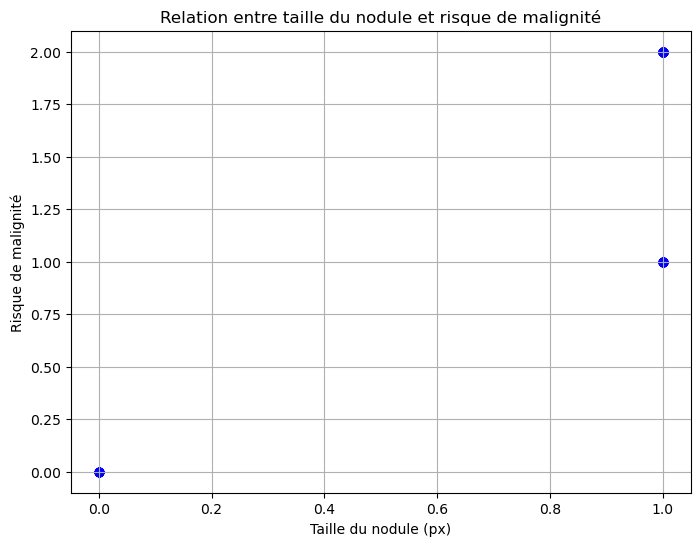

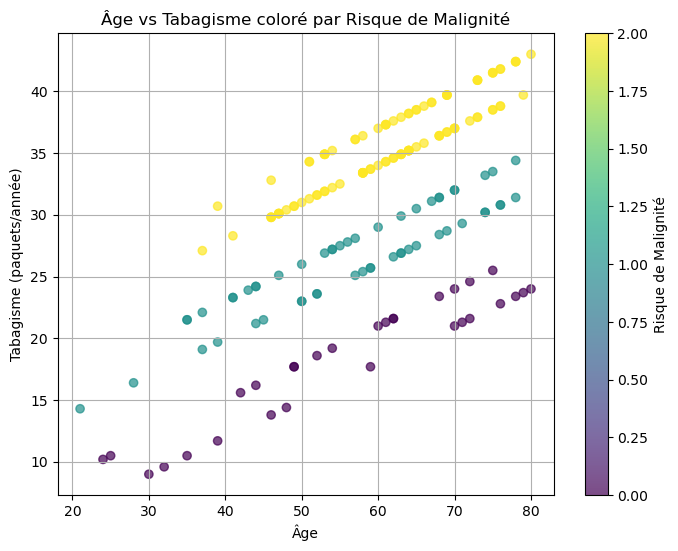

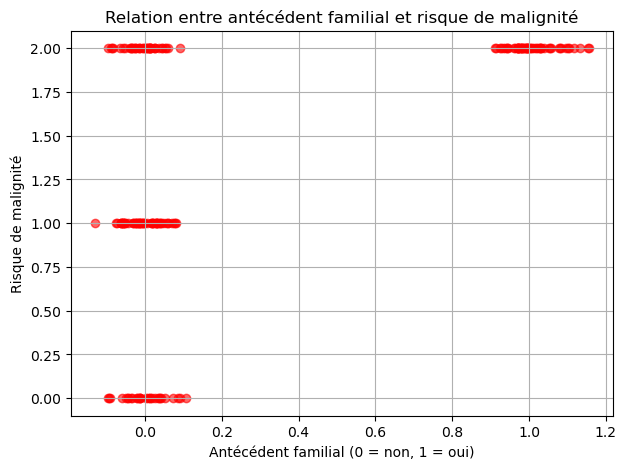

In [5]:
#Relation entre taille du nodule et risque de malignité 


plt.figure(figsize=(8, 6))
plt.scatter(data['taille_nodule_px'], data['risque_malignite'], alpha=0.6, color='blue')
plt.title("Relation entre taille du nodule et risque de malignité")
plt.xlabel("Taille du nodule (px)")
plt.ylabel("Risque de malignité")
plt.grid(True)
plt.show()



#Age vs Tabagisme coloré par Risque de Malignité
    
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    data['age'], 
    data['tabagisme_paquets_annee'], 
    c=data['risque_malignite'],      
    cmap='viridis',                  
    alpha=0.7
)
plt.xlabel("Âge")
plt.ylabel("Tabagisme (paquets/année)")
plt.title("Âge vs Tabagisme coloré par Risque de Malignité")
plt.colorbar(scatter, label="Risque de Malignité") 
plt.grid(True)
plt.show()



#Relation entre antécédent familial et risque de malignité"
    
plt.figure(figsize=(7, 5))
x_jitter = data['antecedent_familial'] + np.random.normal(0, 0.05, size=len(data))
plt.scatter(x_jitter, data['risque_malignite'], alpha=0.6, color='red')
plt.xlabel("Antécédent familial (0 = non, 1 = oui)")
plt.ylabel("Risque de malignité")
plt.title("Relation entre antécédent familial et risque de malignité")
plt.grid(True)
plt.show()


Visualisation de l'Imagerie (JSRT Subset)

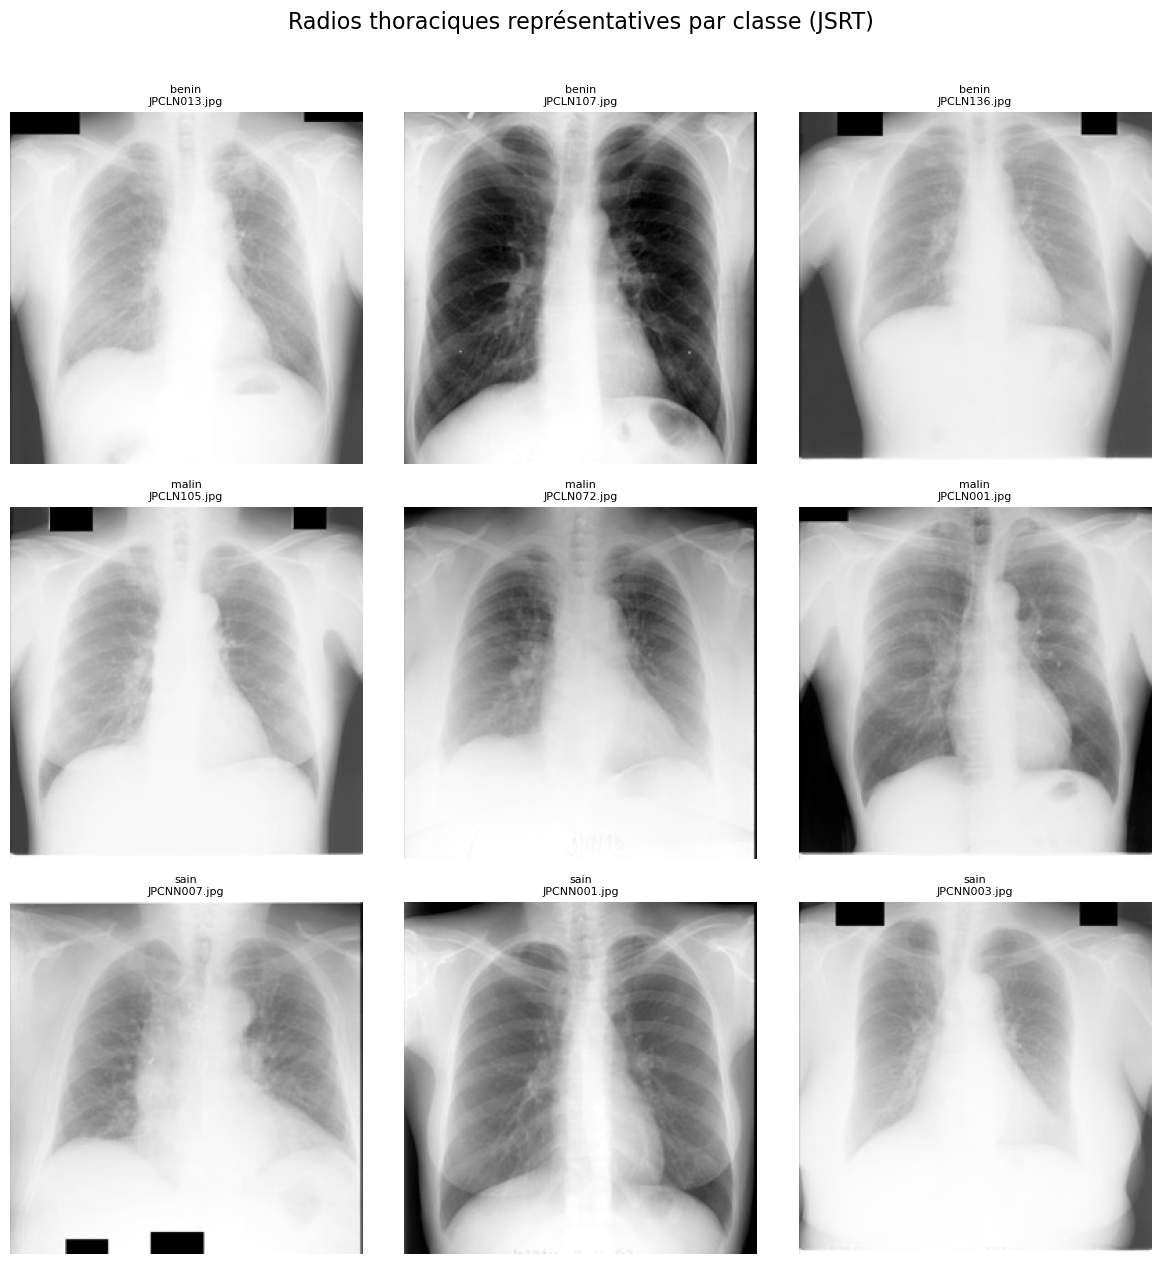

In [6]:
def plot_samples_from_parent_folder(parent_folder, n=3):
    # Liste des sous-dossiers (classes)
    classes = [d for d in os.listdir(parent_folder) if os.path.isdir(os.path.join(parent_folder, d))]
    classes.sort()  # ordre fixe
    
    # Créer la grille de sous-plots
    fig, axes = plt.subplots(len(classes), n, figsize=(4*n, 4*len(classes)))
    
    # Si axes n'est pas un tableau 2D
    if len(classes) == 1:
        axes = np.expand_dims(axes, axis=0)
    if n == 1:
        axes = np.expand_dims(axes, axis=1)
    
    for i, cls in enumerate(classes):
        folder_path = os.path.join(parent_folder, cls)
        
        # Récupérer toutes les images
        img_files = [f for f in os.listdir(folder_path) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if len(img_files) == 0:
            print(f"Aucune image trouvée dans {folder_path}")
            continue
        
        # Mélanger et prendre les n premières
        np.random.shuffle(img_files)
        samples = img_files[:n]
        
        for j, img_name in enumerate(samples):
            img_path = os.path.join(folder_path, img_name)
            try:
                img = Image.open(img_path).convert('L')
            except Exception as e:
                print(f"Impossible d'ouvrir {img_path}: {e}")
                continue
            
            # Affichage
            ax = axes[i, j]
            ax.imshow(img, cmap='gray')
            ax.set_title(f"{cls}\n{img_name}", fontsize=8)
            ax.axis('off')
    
    plt.tight_layout()
    plt.suptitle("Radios thoraciques représentatives par classe (JSRT)", fontsize=16, y=1.05)
    plt.show()

# Utilisation
parent_folder = r'C:\Users\celia\Esic TP noté ILDE\TP images'  # dossier parent contenant sain/benin/malin
plot_samples_from_parent_folder(parent_folder, n=3)




# Deuxiéme partie

# Le premier modéle: Régression logistique





Séparation des données

In [7]:
y = data['risque_malignite']  
X = data.drop(columns=['risque_malignite','patient_id','classe_jsrt_source', 'diagnostic_source', 'image_path' ])  # toutes les colonnes sauf le label


Séparation des données en données d'entrainement et de test: 80% pour l'entrainement et 20% pour le test.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       
    random_state=42,     
    stratify=y          
)

print(f"Nombre d'échantillons train : {len(X_train)}")
print(f"Nombre d'échantillons test : {len(X_test)}")



Nombre d'échantillons train : 147
Nombre d'échantillons test : 37


Entrainement de notre modéle

In [9]:

#modèle (multinomial = multi-classes) car on a trois classes: sain, benin et malin
model_lr = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)


#le modèle est ajusté sur les données d’entraînement (X_train, y_train)
model_lr.fit(X_train, y_train)


#le modèle prédit les classes pour les données de test (X_test)
y_pred_lr = model_lr.predict(X_test)


#Évaluation de modéle: mesurer la performance du modèle en termes de précision, rappel et score F1 pour chaque classe,
#afin de savoir à quel point le modèle prédit correctement chaque catégorie.
print(classification_report(y_test, y_pred_lr))


# Export des résultats : les vraies valeurs et les prédictions de modéle 1 sont sauvegardées dans un fichier CSV predictions_logistic_regression.csv 
#Le fichier qui sera utilié par la suite dans la modele 2 version 2
results_df = pd.DataFrame({
    'index': X_test.index,   
    'y_true': y_test,
    'y_pred': y_pred_lr
})

results_df.to_csv("predictions_logistic_regression.csv", index=False)
print("Les prédictions ont été sauvegardées dans 'predictions_logistic_regression.csv'")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37

Les prédictions ont été sauvegardées dans 'predictions_logistic_regression.csv'


# Le deuxiéme modéle

# Modéle 2: version 1  (CNN)

Ce bloc importe les outils nécessaires afin de construire notre modéle CNN

In [10]:
pip install protobuf==3.20.3

Note: you may need to restart the kernel to use updated packages.


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

Ce code définit le chemin du dossier principal contenant les images et crée des chemins spécifiques pour chaque classe (sain, benin, malin) 
afin de pouvoir y accéder

In [12]:

base_dir = r'C:\Users\celia\Esic TP noté ILDE\TP images' 
sain_dir = os.path.join(base_dir, 'sain')
benin_dir = os.path.join(base_dir, 'benin') 
malin_dir = os.path.join(base_dir, 'malin')

Ce code crée un DataFrame listant toutes les images avec leur label associé:

- 0 aux images de la classe sain
- 1 aux images des classes benin et malin

In [13]:

# Création des DataFrames avec chemins et labels 
data_list = []

# Classe 0 : sain
for img_name in os.listdir(sain_dir):
    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        data_list.append([os.path.join(sain_dir, img_name), 0])

# Classe 1 : benin et malin
for folder in [benin_dir, malin_dir]:
    for img_name in os.listdir(folder):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            data_list.append([os.path.join(folder, img_name), 1])

df = pd.DataFrame(data_list, columns=['image_path', 'label'])

In [14]:

#Convertir les labels en chaînes de caractères pour Keras 
#Keras attend souvent que les labels soient des chaînes de caractères pourque  les reconnaisse correctement comme des catégories
df['label'] = df['label'].astype(str)


# La division des données en données de test et aux données d'entrainement (20% pour le test et 80% pour l'entrainement)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])


# DataGenerator simple Ces lignes servent à normaliser les images en divisant les valeurs des pixels par 255, pour que tous les pixels soient dans la plage [0, 1], 
#ce qui facilite l’entraînement du modèle
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)



#Ces générateurs préparent et fournissent les images normalisées et étiquetées par lots au modèle Keras pendant l’entraînement et le test.

img_size = (128, 128)
batch_size = 16

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    color_mode='grayscale',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=True
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=img_size,
    color_mode='grayscale',
    class_mode='binary',
    batch_size=batch_size,
    shuffle=False
)

# Modéle CNN ---
model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # sortie binaire
])

model_cnn.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])




#  Entraînement de  CNN sur les images d’entraînement
history = model_cnn.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20
)



# Prédictions sur les données de test  
test_generator.reset()
y_pred_prob = model_cnn.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)



# Évaluation de modéle
#compare les vraies étiquettes des images de test 
#avec les prédictions du modèle et affiche un rapport de performance (précision, rappel, F1-score) pour chaque classe.

y_true = test_df['label'].astype(int).values  # convert en int pour classification_report
print(classification_report(y_true, y_pred))



# Ces lignes créent un DataFrame avec les chemins des images
#les vraies étiquettes et les prédictions du CNN, puis sauvegardent dans le fichier cvs (predictions_cnn.csv) 
#le fichier csv qui sera utilisé dans le modéle 2 version 2

results_df = pd.DataFrame({
    'image_path': test_df['image_path'],
    'y_true': y_true,
    'y_pred': y_pred
})
results_df.to_csv("predictions_cnn.csv", index=False)
print("Les prédictions CNN ont été sauvegardées dans 'predictions_cnn.csv'")

Found 147 validated image filenames belonging to 2 classes.
Found 37 validated image filenames belonging to 2 classes.


Epoch 1/20


10/10 [==============================] - 6s 232ms/step - loss: 0.5187 - accuracy: 0.8027 - val_loss: 0.4506 - val_accuracy: 0.8378
Epoch 2/20
10/10 [==============================] - 2s 158ms/step - loss: 0.4566 - accuracy: 0.8367 - val_loss: 0.4462 - val_accuracy: 0.8378
Epoch 3/20
10/10 [==============================] - 2s 156ms/step - loss: 0.4617 - accuracy: 0.8367 - val_loss: 0.4468 - val_accuracy: 0.8378
Epoch 4/20
10/10 [==============================] - 2s 152ms/step - loss: 0.4774 - accuracy: 0.8367 - val_loss: 0.4453 - val_accuracy: 0.8378
Epoch 5/20
10/10 [==============================] - 2s 157ms/step - loss: 0.4419 - accuracy: 0.8367 - val_loss: 0.4412 - val_accuracy: 0.8378
Epoch 6/20
10/10 [==============================] - 2s 154ms/step - loss: 0.4485 - accuracy: 0.8367 - val_loss: 0.4410 - val_accuracy: 0.8378
Epoch 7/20
10/10 [=======

C:\Users\celia\.anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\celia\.anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\celia\.anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Modéle 2 : version 2 (Régression logistique)

Chargement des fichiers de prédictions obtenue dans le modéle 1 (régression logistique) et dans le modéle 2 (version 1: CNN)

In [15]:
pred_cnn = pd.read_csv("predictions_cnn.csv")  
pred_reglog = pd.read_csv("predictions_logistic_regression.csv")


Harmonisation des labels : remplacer 2 par 1 dans les prédictions de la régression logistique


In [16]:
# Harmonisation des labels : remplacer 2 par 1 dans les prédictions de la régression logistique
pred_reglog['y_pred'] = pred_reglog['y_pred'].replace(2, 1)
pred_reglog['y_true'] = pred_reglog['y_true'].replace(2, 1)

#Création d'une DataFrame avec les  prédictions des deux modéles

X = pd.DataFrame({
    'cnn': pred_cnn['y_pred'],
    'reglog': pred_reglog['y_pred']
})
y = pred_cnn['y_true']  

print (X)
print ("les vrai valeurs",y)

    cnn  reglog
0     1       1
1     1       1
2     1       1
3     1       1
4     1       1
5     1       1
6     1       1
7     1       1
8     1       1
9     1       1
10    1       1
11    1       1
12    1       1
13    1       1
14    1       0
15    1       1
16    1       1
17    1       1
18    1       0
19    1       1
20    1       1
21    1       1
22    1       1
23    1       1
24    1       0
25    1       1
26    1       0
27    1       0
28    1       1
29    1       1
30    1       1
31    1       1
32    1       1
33    1       1
34    1       1
35    1       0
36    1       1
les vrai valeurs 0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    0
15    1
16    1
17    1
18    0
19    1
20    1
21    1
22    1
23    1
24    0
25    1
26    0
27    0
28    1
29    1
30    1
31    1
32    1
33    1
34    1
35    0
36    1
Name: y_true, dtype: int64


Modéle finale

In [17]:
# Régression logistique finale 
model = LogisticRegression()
model.fit(X, y)
y_pred_final = model.predict(X)

# Évaluation de modéle
print("=== Rapport classification final ===")
print(classification_report(y, y_pred_final))


# Sauvegarde des résultats modéle 2 (version 2) 
results = X.copy()
results['y_true'] = y
results['y_pred_final'] = y_pred_final
results.to_csv("predictions_modéle 2 (V2).csv", index=False)
print("Les prédictions combinées ont été sauvegardées dans 'predictions_modéle 2 (V2).csv'")

=== Rapport classification final ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        31

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37

Les prédictions combinées ont été sauvegardées dans 'predictions_modéle 2 (V2).csv'


Affichage des courbes d'apprentissage

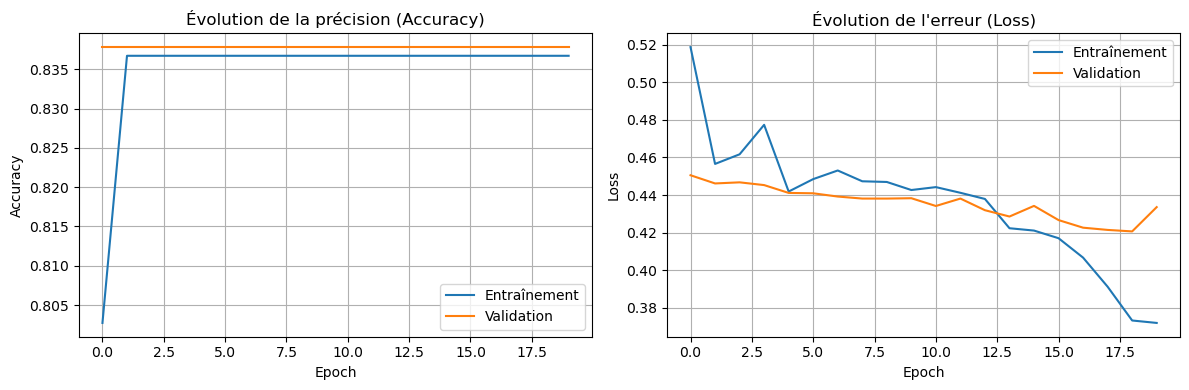

In [18]:

plt.figure(figsize=(12, 4))

# Courbe 1 : Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entraînement')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Évolution de la précision (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Courbe 2 : Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entraînement')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Évolution de l'erreur (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

visualisation de 10 images du test avec leurs vrai valeurs réels

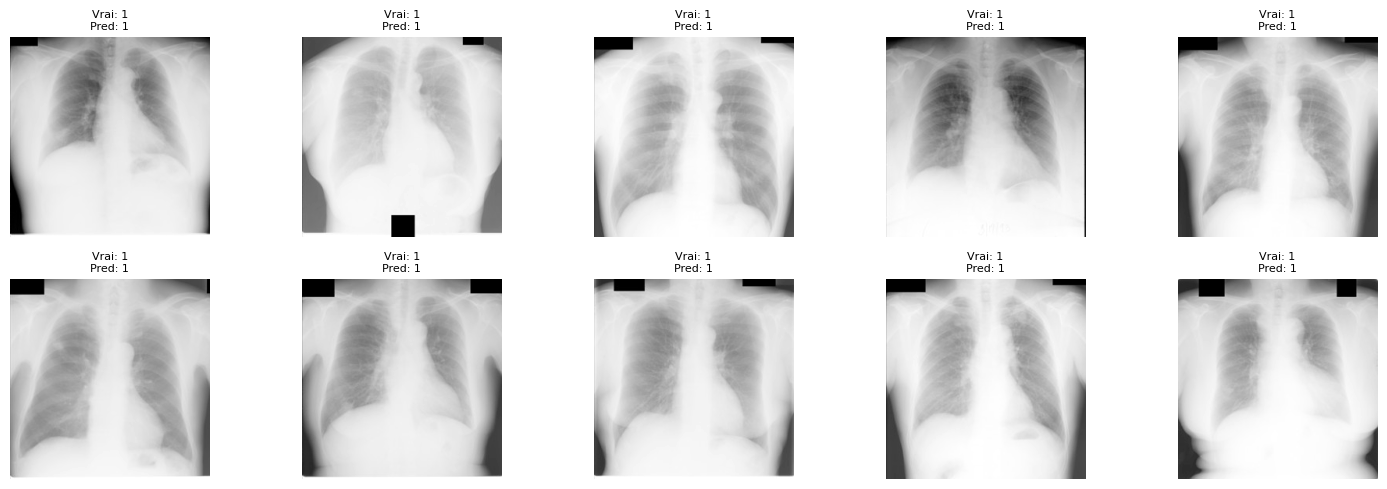

In [19]:

N = 10  # nombre d'images à afficher
subset = results.head(N)

plt.figure(figsize=(15, 5))

for i, row in enumerate(subset.itertuples()):
    img_path = row.Index if 'image_path' in subset.columns else pred_cnn.loc[i, 'image_path']
    img = Image.open(img_path).convert('L')  
    plt.subplot(2, N//2, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Vrai: {row.y_true}\nPred: {row.y_pred_final}", fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()

Sauvegarde du modèle 1

In [20]:

import joblib
joblib.dump(model_lr, "model_lr.pkl")
print("✅ model_lr.pkl sauvegardé !")

✅ model_lr.pkl sauvegardé !


Sauvegarde le modéle 2 version 1 (CNN)

In [21]:
model_cnn.save("model_cnn.h5")
print("✅ Modèle CNN sauvegardé en .h5 !")

✅ Modèle CNN sauvegardé en .h5 !


C:\Users\celia\.anaconda\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Sauvegarde du modèle 2 version 2 

In [22]:
joblib.dump(model, "model_fusion.pkl")
print("✅ model_fusion.pkl sauvegardé !")

✅ model_fusion.pkl sauvegardé !
